# Solutions to Activity 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

For reading, note that you might know IPF as:

- Iterative proportional fitting
- Raking
- IPFP (the p is for procedure...)
- Biproportional sacaling
- RAS algorithm

## 1. Implementing the Classical IPF

Classical IPF proposes that we repeatedly rescale rows and columns of a matrix so that they match known row and column sum constraints. That is, we would like to estimate an $n\times m$-dimensional matrix $A$ and we are given:

- A noisy $n\times m$-dimensional matrix $B$ (for example, a perturbation of $A$, or a sample of $A$).
- An $n$-dimensional vector $X$ which represents the sums of the rows of $A$. That is, the sum of the first row of $A$ is $X_1$, the sum of the second row is $X_2$, etc.
- An $m$-dimensional vector $Y$ which represents the sums of the columns of $A$.  That is, the sum of the first column of $A$ is $Y_1$, etc.

For example, if we knew $A$ was:

In [2]:
A = np.array([[40, 50, 12, 30],
              [20, 30, 50, 10],
              [30, 20, 10, 40],
              [10, 40, 30, 20],
              [5, 40, 30, 20]])

Question: What are $n$ and $m$? What are $X$ and $Y$? Define them below:

In [3]:
n = A.shape[0] #5
m = A.shape[1] #4
X = A.sum(axis=1) #np.array([132, 110, 100, 100, 95])
Y = A.sum(axis=0) #np.array([105, 180, 132, 120])

#Can you compute the row and column sums of A to produce X and Y?

Now, forget you ever saw the matrix $A$! You only saw a matrix $B$, which is:

In [4]:
B = np.array([[8, 11, 2, 1],
              [5, 20, 3, 2],
              [6, 1, 2, 6],
              [2, 8, 6, 4],
              [4, 7, 5, 8]], dtype=float) #Note that we need to use floats here, otherwise the multipliers below will be rounded to integers!
B0 = B.copy() #Keep a copy of the initial matrix for comparison later

Complete the function above to apply the iterative proportional fitting algorithm to $B$ and estimate $A$:


Iteration 1
[13.02753167  8.42846191  3.54288702 10.47211599  7.44099057]
[1.42108547e-14 0.00000000e+00 0.00000000e+00 1.42108547e-14]

Iteration 2
[2.12807864 1.65321773 1.54891955 0.95281088 1.27956594]
[1.42108547e-14 0.00000000e+00 2.84217094e-14 2.84217094e-14]

Iteration 3
[0.38799405 0.35953384 0.38511158 0.11870775 0.24370855]
[0.00000000e+00 2.84217094e-14 0.00000000e+00 1.42108547e-14]

Iteration 4
[0.07700834 0.07700034 0.08562458 0.01899399 0.04939011]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 2.84217094e-14]

Iteration 5
[0.01587086 0.01633996 0.01840026 0.00354822 0.01026234]
[1.42108547e-14 0.00000000e+00 0.00000000e+00 2.84217094e-14]

Iteration 6
[0.00331922 0.00345486 0.00390803 0.00071327 0.00215279]
[0.00000000e+00 2.84217094e-14 0.00000000e+00 1.42108547e-14]

Iteration 7
[0.00069802 0.00072949 0.00082653 0.00014775 0.00045323]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.42108547e-14]

Iteration 8
[1.47089626e-04 1.53953242e-04 1.74538653e-04 3.09580258e-

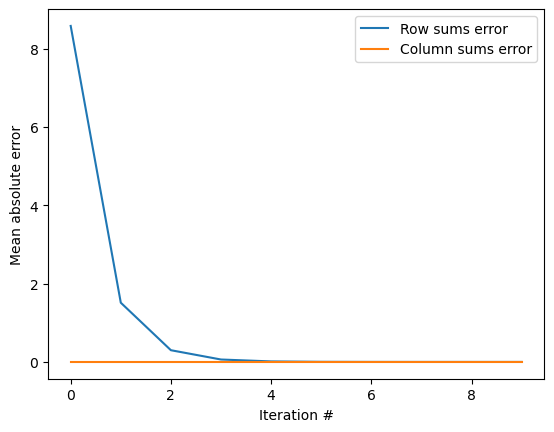

In [5]:
n_iterations = 10

#For the plot:
row_sums_per_iteration, col_sums_per_iteration = [], []

#This version uses for loops over the rows and columns---feel free to vectorize!
# Be careful with the dimensions of the arrays! Use print statements to check them if you are unsure.
for iteration in range(n_iterations):
    print(f'\nIteration {iteration+1}')

    #Rescale the rows of B to match the row sums X:
    current_row_sums_in_B = B.sum(axis=1) #a 1-dimensional numpy array of the current row sums of B
    for i in range(n):
        multiplier = X[i]/current_row_sums_in_B[i] #the multiplier to rescale row i of B to match X[i], which will depend on current_row_sums_in_B[i] and X[i]
        B[i, :] = B[i, :] * multiplier
    
    #Rescale the columns of B to match the column sums Y:
    current_col_sums_in_B = B.sum(axis=0) #a 1-dimensional numpy array of the current column sums of B
    for j in range(m):
        multiplier = Y[j]/current_col_sums_in_B[j]  #the multiplier to rescale col j of B to match Y[j], which will depend on current_col_sums_in_B[j] and Y[j]
        B[:, j] = B[:, j] * multiplier

    #Print the difference between the row sum of B and X, and the difference between the column sum of B and Y
    print(abs(B.sum(axis=1) - X)) #Should be close to X
    print(abs(B.sum(axis=0) - Y)) #Should be close to Y
    #Can you visualize the average of these errors over the iterations with plt.plot()?
    row_sums_per_iteration.append(np.mean(abs(B.sum(axis=1) - X)))
    col_sums_per_iteration.append(np.mean(abs(B.sum(axis=0) - Y)))

plt.plot(row_sums_per_iteration, label='Row sums error')
plt.plot(col_sums_per_iteration, label='Column sums error')
plt.xlabel('Iteration #')
plt.ylabel('Mean absolute error')
plt.legend()

Compare $A$ and (the inferred) $B$

In [6]:
A

array([[40, 50, 12, 30],
       [20, 30, 50, 10],
       [30, 20, 10, 40],
       [10, 40, 30, 20],
       [ 5, 40, 30, 20]])

In [7]:
B

array([[42.00008451, 60.27930489, 21.5331792 ,  8.18742485],
       [15.6484517 , 65.33512681, 19.25487067,  9.76154396],
       [29.26489278,  5.09109335, 20.00523532, 45.63878632],
       [ 6.92208295, 28.90095298, 42.58690074, 21.59006471],
       [11.16448805, 20.39352197, 28.61981407, 34.82218017]])

To vectorize the algorithm, you can use diagonal matrices to multiply:

In [8]:
n_iterations = 10

B = B0.copy() #Reset B to the initial matrix
for iteration in range(n_iterations):
    # Rescale rows
    current_row_sums_in_B = B.sum(axis=1)
    B = np.diag(X / current_row_sums_in_B) @ B #multiply on the left by a diagonal matrix

    # Rescale columns
    current_col_sums_in_B = B.sum(axis=0)
    B = B @ np.diag(Y / current_col_sums_in_B) #multiply on the right by a diagonal matrix

## IPF in survey weighting

One very useful property of IPF is that when it converges the solution is unique. And it can be used in survey weighting---something you may find very useful!

- Let's say you surveyed a population of 537 people.
- Each person was classified in one of 4 income groups (1st quartile, 2nd quartile, 3rd quartile, 4th quartile)
- Each person was classified in one of 5 age groups (Under 18, 18-30, 30-50, 50-65, Above 65)

You know the total number of people in each age group per each income group via the Census---assume that's our matrix A

In [9]:
A_as_dataframe = pd.DataFrame(A, columns=['Income 1st quartile', 'Income 2nd quartile', 'Income 3rd quartile', 'Income 4th quartile'],
                              index=['Age < 18', 'Age 18-30', 'Age 30-50', 'Age 50-65', 'Age > 65'])
display(A_as_dataframe)

,Income 1st quartile,Income 2nd quartile,Income 3rd quartile,Income 4th quartile
Age < 18,40,50,12,30
Age 18-30,20,30,50,10
Age 30-50,30,20,10,40
Age 50-65,10,40,30,20
Age > 65,5,40,30,20


Then you do IPF in the matrix from your sample---for example, if $B$ was the original sample (which we saved as $B0$), we have sampled:

In [10]:
B_as_dataframe = pd.DataFrame(B0, columns=['Income 1st quartile', 'Income 2nd quartile', 'Income 3rd quartile', 'Income 4th quartile'],
                 index=['Age < 18', 'Age 18-30', 'Age 30-50', 'Age 50-65', 'Age > 65'])
display(B_as_dataframe)

,Income 1st quartile,Income 2nd quartile,Income 3rd quartile,Income 4th quartile
Age < 18,8.0,11.0,2.0,1.0
Age 18-30,5.0,20.0,3.0,2.0
Age 30-50,6.0,1.0,2.0,6.0
Age 50-65,2.0,8.0,6.0,4.0
Age > 65,4.0,7.0,5.0,8.0


The weight of an individual in a survey is the relative value of that individual's response. If your sample is truly random, all weights should be equal. But often you may find that you oversampled some population, or undersampled some population. IPF ``corrected`` your sample, producing weights for each individaul---the ratio of the inferred to the original values:

In [11]:
w_as_dataframe = pd.DataFrame(B/B0, columns=['Income 1st quartile', 'Income 2nd quartile', 'Income 3rd quartile', 'Income 4th quartile'],
                 index=['Age < 18', 'Age 18-30', 'Age 30-50', 'Age 50-65', 'Age > 65'])
display(w_as_dataframe.round(2))

,Income 1st quartile,Income 2nd quartile,Income 3rd quartile,Income 4th quartile
Age < 18,5.25,5.48,10.77,8.19
Age 18-30,3.13,3.27,6.42,4.88
Age 30-50,4.88,5.09,10.00,7.61
Age 50-65,3.46,3.61,7.10,5.40
Age > 65,2.79,2.91,5.72,4.35


So for example the weights reveal that you would need to value the responses of a 3rd-income quartile 17 year old ($w=10.77$) over twice as much as those of a 1st income quartile 17 year old ($w=5.25$). Note that weights are all greater than 1 because $B$ at first summed to a value much below $A$---to actually understand representation, you could have rescaled $B$ by multiplying every entry by $A.sum()/B.sum()$.

For further reading, and especially if you are truly interested in using IPF in sample weighting, there exist more advanced methods to do IPF which also try to minimize other survey problems. For example, weights that are close to uniform tend to be better---to avoid disproportionately valuing a few responses. Generalized raking solves this issue, here is a [nice read](https://dev.to/potloc/generalized-raking-for-survey-weighting-2d1d) with code snippets.